In [73]:
#importing
import csv
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
import keras
import pandas as pd
import xgboost as xgb
from scipy.stats import norm
from scipy.signal import chirp, find_peaks, peak_widths

In [74]:
XGBoost_data = np.loadtxt('XGBoost_distances_xgboost.csv')
MLP_data = np.loadtxt('MLP_distances.csv')

In [75]:
XGBoost_best = XGBoost_data.reshape((-1, 331, 331))[19]
MLP_best = MLP_data.reshape((-1, 331, 331))[19]

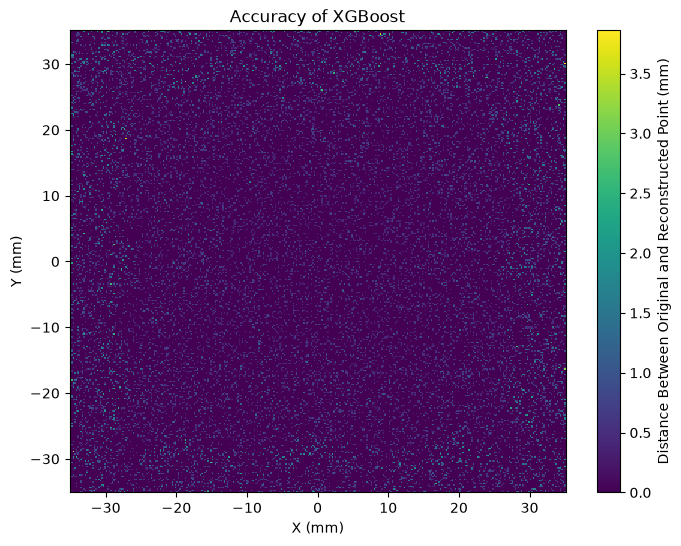

In [76]:
#XGBoost Color Map
xaxis = 1000*np.linspace(-0.035, 0.035, 331)
yaxis = 1000*np.linspace(-0.035, 0.035, 331)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis,yaxis,XGBoost_best,shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of XGBoost')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/accuracy_xgb.png',dpi=300,bbox_inches='tight')
plt.show()


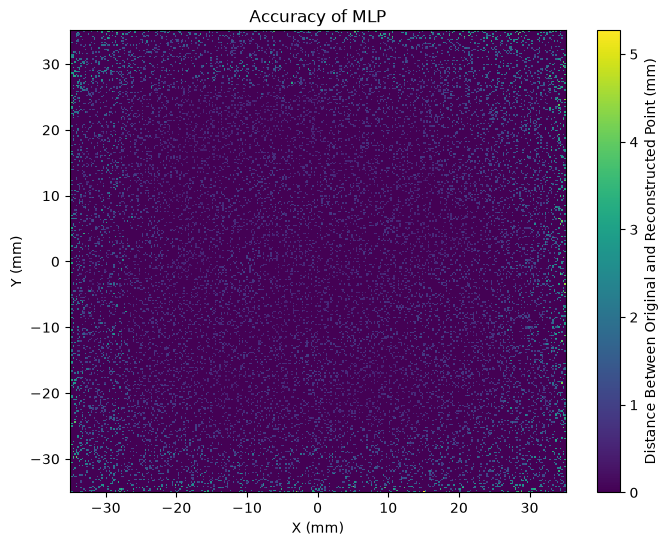

In [77]:
#MLP Color Map
xaxis = 1000*np.linspace(-0.035, 0.035, 331)
yaxis = 1000*np.linspace(-0.035, 0.035, 331)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis,yaxis,MLP_best,shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of MLP')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/accuracy_mlp.png',dpi=300,bbox_inches='tight')
plt.show()

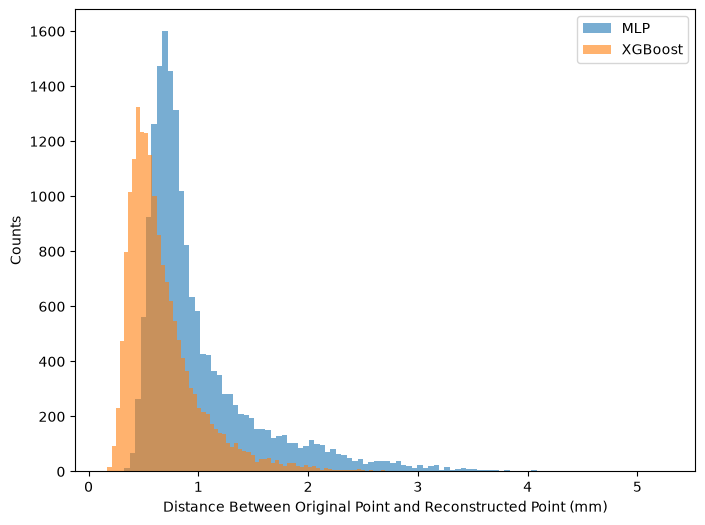

In [78]:
#Histogram comparing both methods
MLP_distances = MLP_best.ravel()
XGBoost_distances = XGBoost_best.ravel()
MLP_distances = MLP_distances[MLP_distances != 0]
XGBoost_distances = XGBoost_distances[XGBoost_distances != 0]

plt.figure(figsize=(8, 6))
plt.hist(MLP_distances,bins=100,alpha=0.6,label='MLP')
plt.hist(XGBoost_distances,bins=100,alpha=0.6,label='XGBoost')
plt.xlabel('Distance Between Original Point and Reconstructed Point (mm)')
plt.ylabel('Counts')
plt.legend(loc='upper right')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/histogram_mlp_xgb.png',dpi=300,bbox_inches='tight')
plt.show()


In [79]:
#Averages
for i in range(20):
    print("Average XGBoost Distance (mm): " + str(np.average(XGBoost_data[i])))
    print("Average MLP Distance (mm): " + str(np.average(MLP_data[i])))

Average XGBoost Distance (mm): 0.13468416894052873
Average MLP Distance (mm): 0.198564699850853
Average XGBoost Distance (mm): 0.13356343078890726
Average MLP Distance (mm): 0.199850609537264
Average XGBoost Distance (mm): 0.5384224398729484
Average MLP Distance (mm): 0.646290288780353
Average XGBoost Distance (mm): 0.13185550240962218
Average MLP Distance (mm): 0.19275024585537462
Average XGBoost Distance (mm): 0.13175631231781085
Average MLP Distance (mm): 0.19018033523090314
Average XGBoost Distance (mm): 0.13337447551046705
Average MLP Distance (mm): 0.19502556999422066
Average XGBoost Distance (mm): 0.13217050689769452
Average MLP Distance (mm): 0.19004576318865302
Average XGBoost Distance (mm): 0.1326827353284169
Average MLP Distance (mm): 0.1914341559082682
Average XGBoost Distance (mm): 0.13425419532347452
Average MLP Distance (mm): 0.19091121633763006
Average XGBoost Distance (mm): 0.13258266426257045
Average MLP Distance (mm): 0.19057559818110187
Average XGBoost Distance (mm)

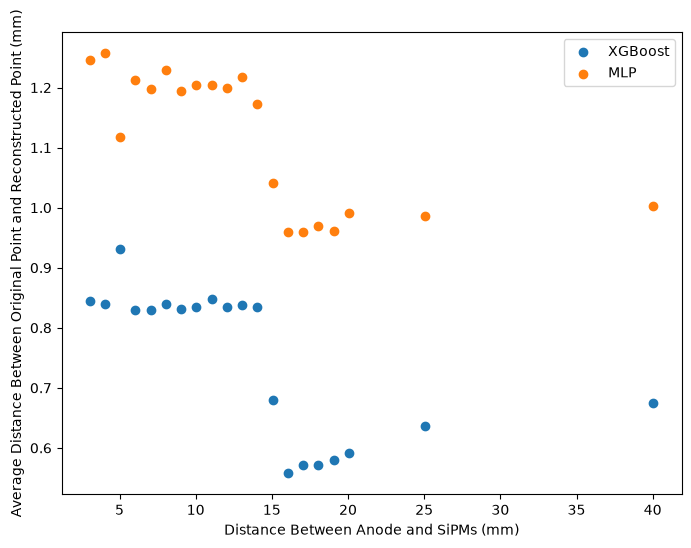

In [80]:
#Scatter Plot of SiPM-Anode distance
x = [3.05, 4.05, 5.05, 6.05, 7.05,8.05, 9.05, 10.05, 11.05, 12.05,13.05, 14.05, 15.05, 16.05, 17.05, 18.05, 19.05, 20.05, 25.05, 40.05]
XGBoosty = []
MLPy = []

for i in range(len(x)):
    XGBoost_values = XGBoost_data[i]
    MLP_values = MLP_data[i]
    XGBoost_values = XGBoost_values[XGBoost_values != 0]
    MLP_values = MLP_values[MLP_values != 0]
    XGBoosty.append(np.average(XGBoost_values))
    MLPy.append(np.average(MLP_values))

plt.figure(figsize=(8, 6))
plt.scatter(x, XGBoosty, label='XGBoost')
plt.scatter(x, MLPy, label='MLP')
plt.xlabel('Distance Between Anode and SiPMs (mm)')
plt.ylabel('Average Distance Between Original Point and Reconstructed Point (mm)')
plt.legend(loc='upper right')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/scatter_mlp_xgb.png',dpi=300,bbox_inches='tight')
plt.show()

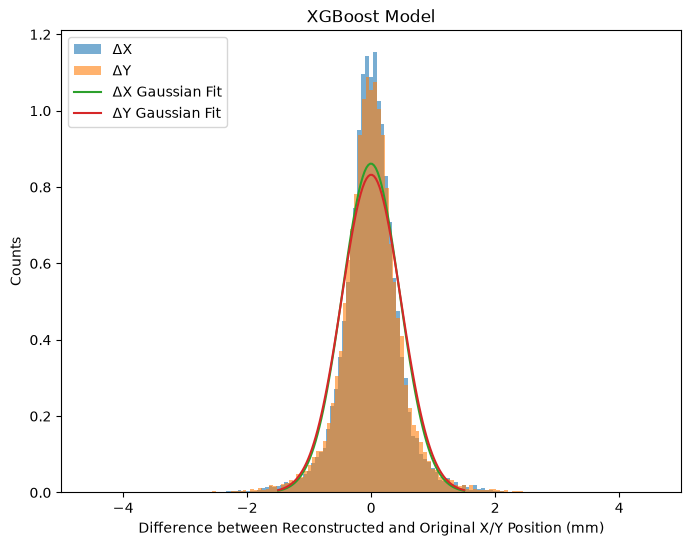

XGBoost FWHM:
[[1.0904643  1.12869103]]
XGBoost Means:
[[-0.00300319 -0.00023136]]
RMSE X: 0.46305190454470607 mm
RMSE Y: 0.4792743780980922 mm
RMSE XY: 0.47123295502532114 mm


In [81]:
# XGBoost Delta

XGBoost_delta_data = np.loadtxt('XGBoost_distances_delta.csv')
XGBoost_delta_data = XGBoost_delta_data.reshape((20, 331, 331,2))

#[i] is the index
element = XGBoost_delta_data[19]
delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]
delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []
meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)
standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)

x_gaussian = np.linspace(-1.5, 1.5, 100)
xy = norm.pdf(x_gaussian,meanx,stdx)
yy = norm.pdf(x_gaussian,meany,stdy)

plt.plot(x_gaussian,xy,label='ΔX Gaussian Fit')
plt.plot(x_gaussian,yy,label='ΔY Gaussian Fit')
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('XGBoost Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/xgb.png',dpi=300,bbox_inches='tight')
plt.show()

print("XGBoost FWHM:")
print(np.array(standard_deviations) * 2.355)
print("XGBoost Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")

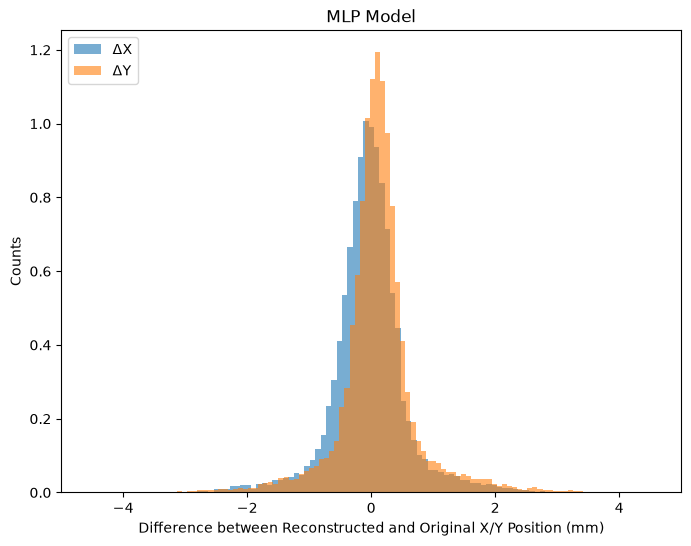

MLP Means:
[[-0.03634349  0.11153877]]
RMSE X: 0.6196196519126237 mm
RMSE Y: 0.6580205553879106 mm
RMSE XY: 0.6391085840251778 mm


In [82]:
#MLP Delta
MLP_delta_data = np.loadtxt('MLP_distances_delta.csv')
MLP_delta_data = MLP_delta_data.reshape((20, 331, 331, 2))

element = MLP_delta_data[19]
delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]

delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('MLP Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/mlp.png',dpi=300,bbox_inches='tight')
plt.show()


# print("MLP FWHM:")
# print(np.array(standard_deviations) * 2.355)

print("MLP Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")


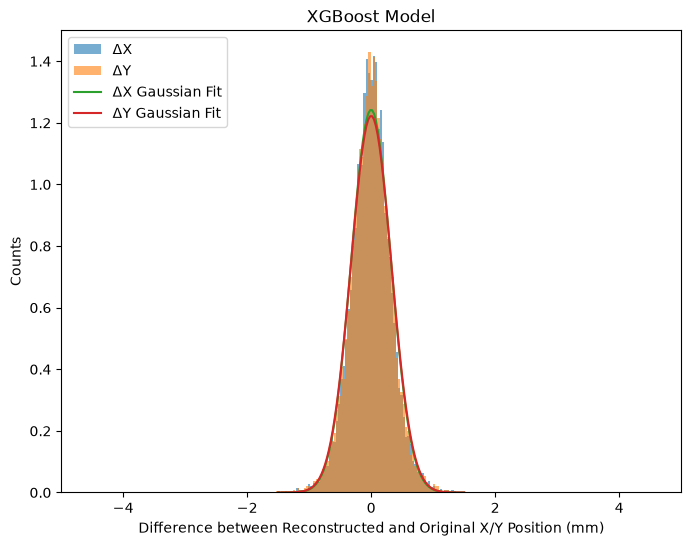

XGBoost cut FWHM:
[[0.75607842 0.76827025]]
XGBoost cut Means:
[[-9.39569717e-04 -7.04617653e-05]]
RMSE X: 0.32105378174288696 mm
RMSE Y: 0.32622941375746956 mm
RMSE XY: 0.32365194358442495 mm


In [83]:
# XGBoost Cut 
XGBoost_data_cut = np.loadtxt('XGBoost_distances_delta_cut.csv')
XGBoost_data_cut = XGBoost_data_cut.reshape((20, 301, 301, 2))
element = XGBoost_data_cut[19]

delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]
delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)

x_gaussian = np.linspace(-1.5, 1.5, 100)
xy = norm.pdf(x_gaussian,meanx,stdx)
yy = norm.pdf(x_gaussian,meany,stdy)

plt.plot(x_gaussian,xy,label='ΔX Gaussian Fit')
plt.plot(x_gaussian,yy,label='ΔY Gaussian Fit')
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('XGBoost Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/xgb_cut.png',dpi=300,bbox_inches='tight')
plt.show()

print("XGBoost cut FWHM:")
print(np.array(standard_deviations) * 2.355)

print("XGBoost cut Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")

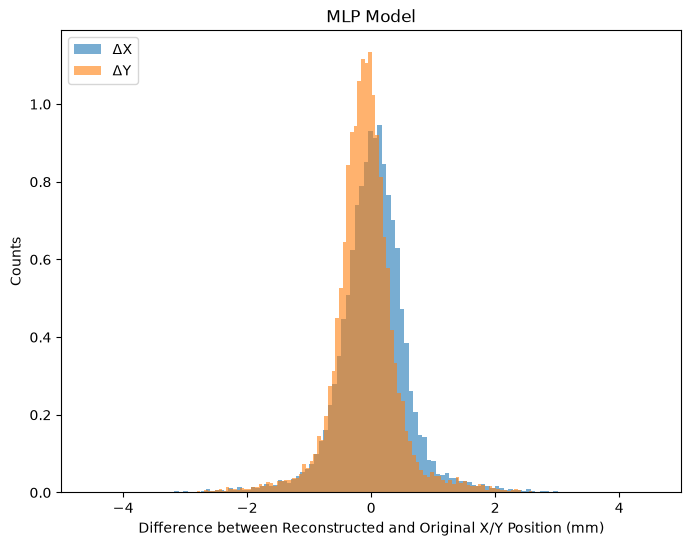

MLP cut Means:
[[ 0.03189696 -0.09962261]]
RMSE X: 0.5758515997710087 mm
RMSE Y: 0.5306670875582414 mm
RMSE XY: 0.5537204271003446 mm


In [84]:
#MLP Cut Delta
MLP_data_cut = np.loadtxt('MLP_distances_delta_cut.csv')
MLP_data_cut = MLP_data_cut.reshape((20, 301, 301, 2))

element = MLP_data_cut[19]

delta = element.reshape(-1, 2)
delta = delta[~np.all(delta == 0, axis=1)]

delta_x = delta[:, 0]
delta_y = delta[:, 1]

standard_deviations = []
means = []

meanx, stdx = norm.fit(delta_x)
meany, stdy = norm.fit(delta_y)

standard_deviations.append([stdx, stdy])
means.append([meanx, meany])

plt.figure(figsize=(8, 6))
plt.hist(delta_x,bins=100,alpha=0.6,label='ΔX',density=True)
plt.hist(delta_y,bins=100,alpha=0.6,label='ΔY',density=True)
plt.xlim(left=-5,right=5)
plt.legend(loc='upper left')
plt.xlabel('Difference between Reconstructed and Original X/Y Position (mm)')
plt.ylabel('Counts')
plt.title('MLP Model')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/mlp_cut.png',dpi=300,bbox_inches='tight')
plt.show()

# print("MLP cut FWHM:")
# print(np.array(standard_deviations) * 2.355)

print("MLP cut Means:")
print(np.array(means))

rmse_x = np.sqrt(np.mean(delta_x**2))
rmse_y = np.sqrt(np.mean(delta_y**2))
rmse_xy = np.sqrt(np.mean((delta_x**2 + delta_y**2) / 2))

print("RMSE X:", rmse_x, "mm")
print("RMSE Y:", rmse_y, "mm")
print("RMSE XY:", rmse_xy, "mm")


In [85]:
MLP_data_cut_distances = np.zeros((20, 301, 301))
for a in range(20):
    for b in range(301):
        for c in range(301):
            MLP_data_cut_distances[a][b][c] = math.dist(MLP_data_cut[a][b][c],[0, 0])

for array in MLP_data_cut_distances:
    print(np.average(array))

0.10800741896170708
0.09297964856600704
0.32340454836380395
0.08804721061012577
0.09232615775931316
0.09843745119163513
0.09468348868883864
0.09685116901779431
0.09208590687296911
0.09443648509906423
0.09781307470396111
0.08627878948722759
0.08693524938957399
0.08038818051609894
0.0924773220321221
0.0922148535490908
0.09126124902816332
0.09088133519651112
0.09112352289543275
0.09762472298360901


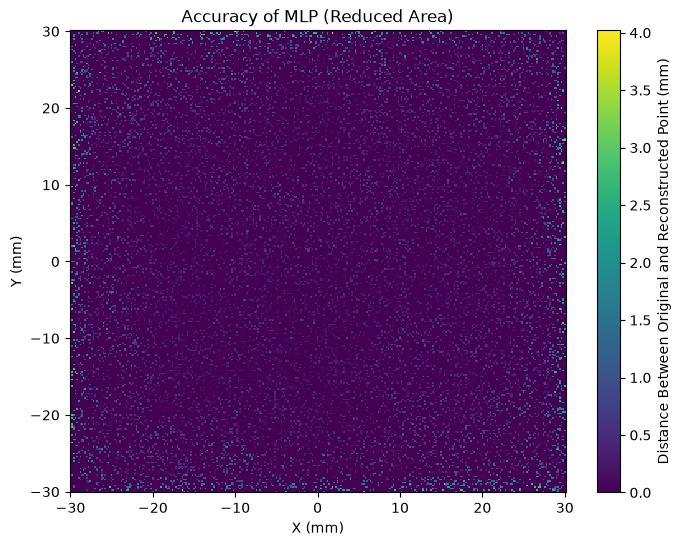

In [86]:
#MLP Cut Accuracy Plot
xaxis_cut = 1000*np.linspace(-0.0300,0.0300,301)
yaxis_cut = 1000*np.linspace(-0.0300,0.0300,301)
MLP_data_cut_distances = np.sqrt(MLP_data_cut[:, :, :, 0]**2 +MLP_data_cut[:, :, :, 1]**2)

plt.figure(figsize=(8, 6))
plt.pcolormesh(xaxis_cut,yaxis_cut,MLP_data_cut_distances[10],shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of MLP (Reduced Area)')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/accuracy_mlp_cut',dpi=300,bbox_inches='tight')
plt.show()




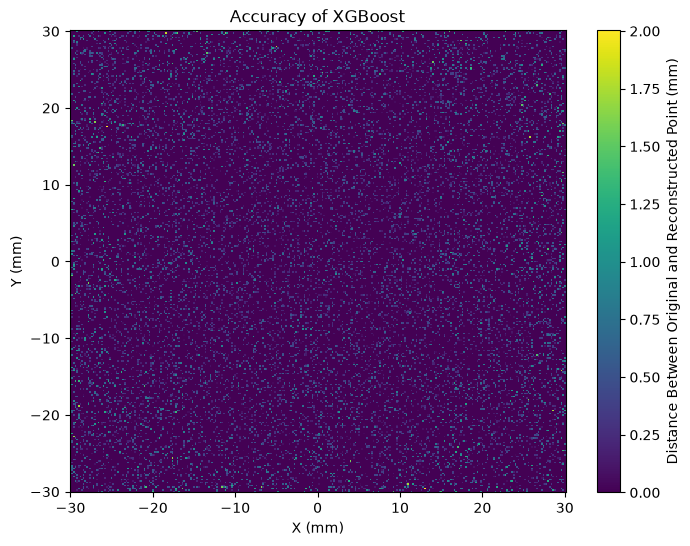

In [87]:
#XGBoost Cut Accuracy Plot
plt.figure(figsize=(8, 6))
XGBoost_data_cut_distances = np.sqrt(XGBoost_data_cut[:, :, :, 0]**2 +XGBoost_data_cut[:, :, :, 1]**2)
plt.pcolormesh(xaxis_cut,yaxis_cut,XGBoost_data_cut_distances[19],shading='auto',cmap='viridis')
plt.colorbar(label='Distance Between Original and Reconstructed Point (mm)')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.title('Accuracy of XGBoost')
plt.savefig('/Users/judyz/Desktop/PET-4x4/build/40.05mm/accuracy_xgb_cut.png',dpi=300,bbox_inches='tight')
plt.show()